In [1]:
import pwbarycentres as pwb
from graph_dp import SinkhornDataProcessor
from utils import *

import pickle
import torch

import os 


In [ ]:
group1 Boundary, rotation and orientation (Set1-Set4)
group 2 Double penalty (Set5)
group 3 Barycentres can form off the support (Set6)
group 4 Clustering (Set7 and Set8)
group 5 Noise cases (Set9)
group 6 Pathological cases (Set10)
group 7 Spatial bias (Set11-Set14)
group 8 Intensity error, equal total mass (set15-17)
group 9 Intensity Error, unequal mass, fixed support (Set18-20)
group 10 Extreme events (Set 21, 22)
group 11 Multiscale events (set23-25)


In [2]:
assert 0

AssertionError: 

## Sensitive to boundry and orientation

In [ ]:
# I should abstract this...
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
count = 0
# 1) generate circle at centre
data_list = []
for mem in members:
    F, X = generate_circle_ensemble(mem, 30, path_to_data, seed_pert=11)

    data_list.append([F, None])

# generate the observation too as a random perturbation
O, X = generate_circle_ensemble(0, 30, path_to_data, seed_pert=11)

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )

count += 1

# 2) generate circle off centre
data_list = []
for mem in members:
    F, X = generate_circle_ensemble(mem, 30, path_to_data, seed_pert=7)
    F = np.roll(F, 40, axis=1)
    F = np.roll(F, 40, axis=0)
    data_list.append([F, None])

# generate the observation too as a random perturbation
O, X = generate_circle_ensemble(0, 30, path_to_data, seed_pert=7)
O = np.roll(O, 40, axis=1)
O = np.roll(O, 40, axis=0)

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )

count += 1

#3) generatre ellipse at centre
data_list = []
for mem in members:
    F, X = generate_ellipse_ensemble(mem, 30, path_to_data, seed_pert=5)

    data_list.append([F, None])

# generate the observation too as a random perturbation
O, X = generate_ellipse_ensemble(0, 30, path_to_data, seed_pert=5)

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )

count += 1

# 4) generatre ellipse at angle
data_list = []
for mem in members:
    F, X = generate_ellipse_ensemble(mem, 30, path_to_data, seed_pert=12, case='E2')

    data_list.append([F, None])

# generate the observation too as a random perturbation
O, X = generate_ellipse_ensemble(0, 30, path_to_data, seed_pert=12, case='E2')

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )

count += 1

dictionary_in_time['times'] = [k for k in range(count)]
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


/tmp/ipykernel_210929/1611455665.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


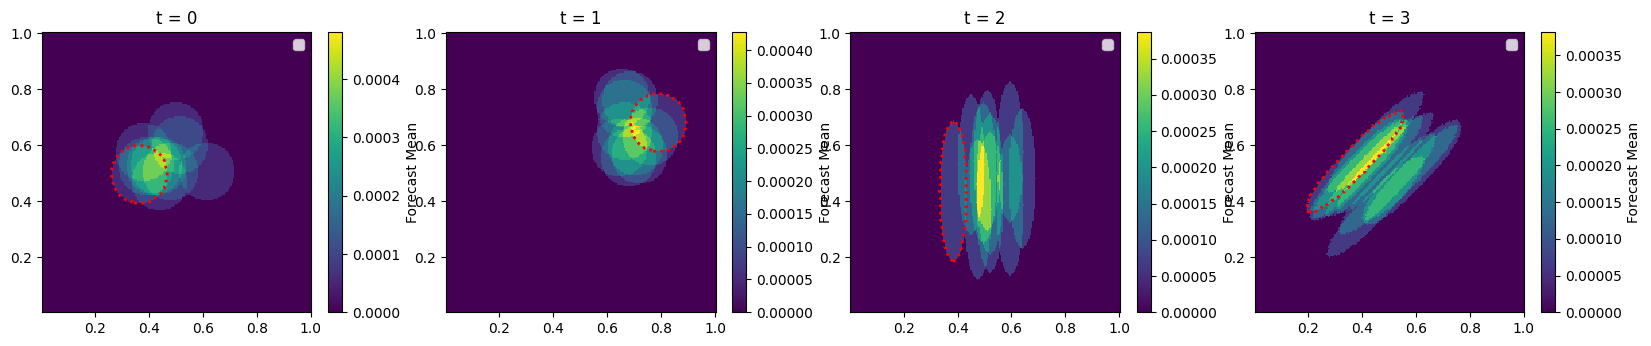

In [ ]:
T = len(dictionary_in_time['times'])
times = dictionary_in_time['times']
M = len(dictionary_in_time['members'])
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))


for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    mask = obs[0]>0
    ax.contour(
        X[:, :, 0],
        X[:, :, 1],
        mask.astype(int),
        levels=[0.5],
        colors='red',
        linestyles='dotted',
        linewidths=2,
        label='Observation'
    )
    ax.legend()

plt.savefig('dataset_1.png', dpi=300)

#### Rotated cases

In [8]:
# I should abstract this...
times = [0, 1, 2, 3, 4]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_rotated_ellipse_ensemble(mem, np.pi*t/16, path_to_data, seed_pert=1)

        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_rotated_ellipse_ensemble(0, np.pi*t/16, path_to_data, seed_pert=1)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


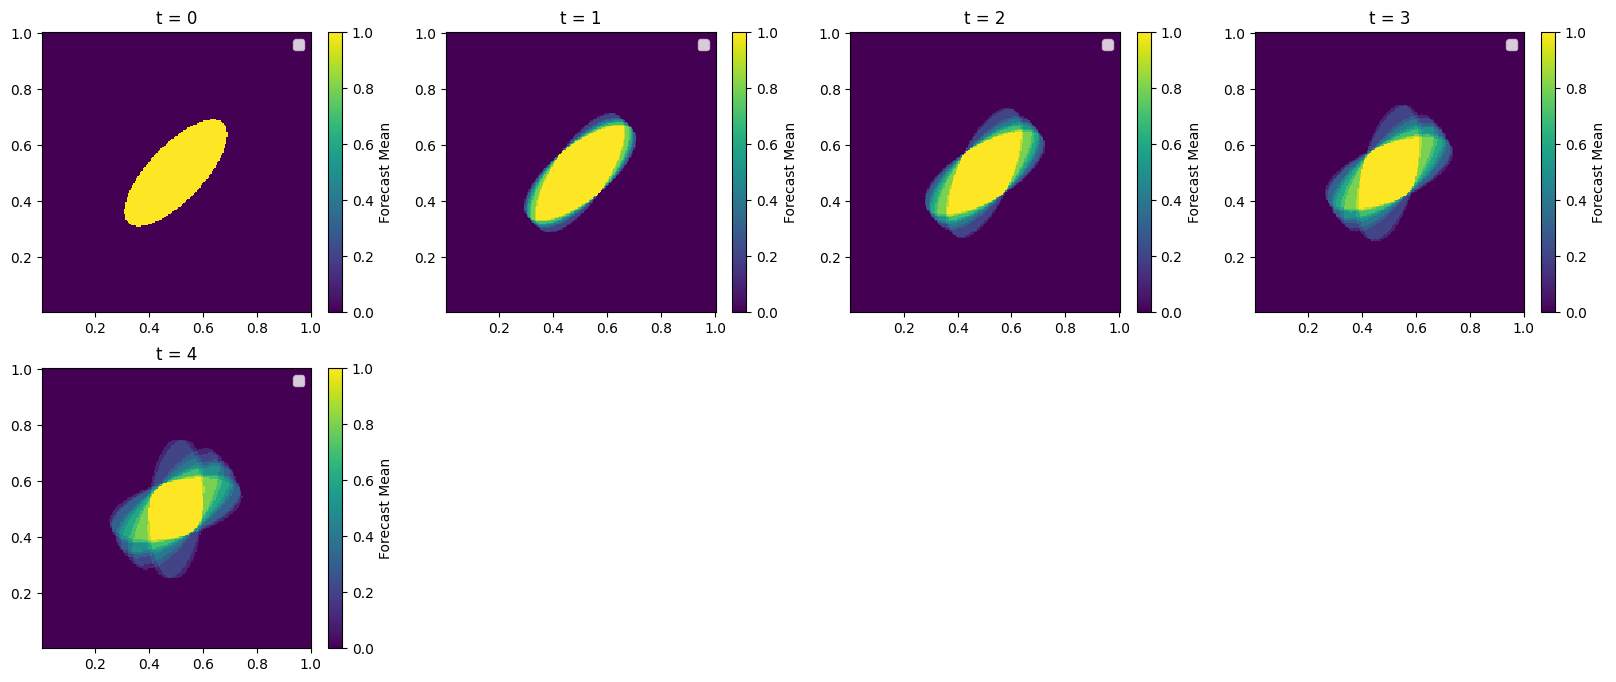

In [9]:
T = len(dictionary_in_time['times'])
times = dictionary_in_time['times']
M = len(dictionary_in_time['members'])
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))


for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_1b.png', dpi=300)

### circular cases for increasing spread
I think I should also explore intensity and shape errors in this simple setting

In [3]:
# I should abstract this...
times = [0, 10, 20, 30, 40, 50, 60, 70, 80]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_circle_ensemble(mem, t, path_to_data)

        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_circle_ensemble(0, t, path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


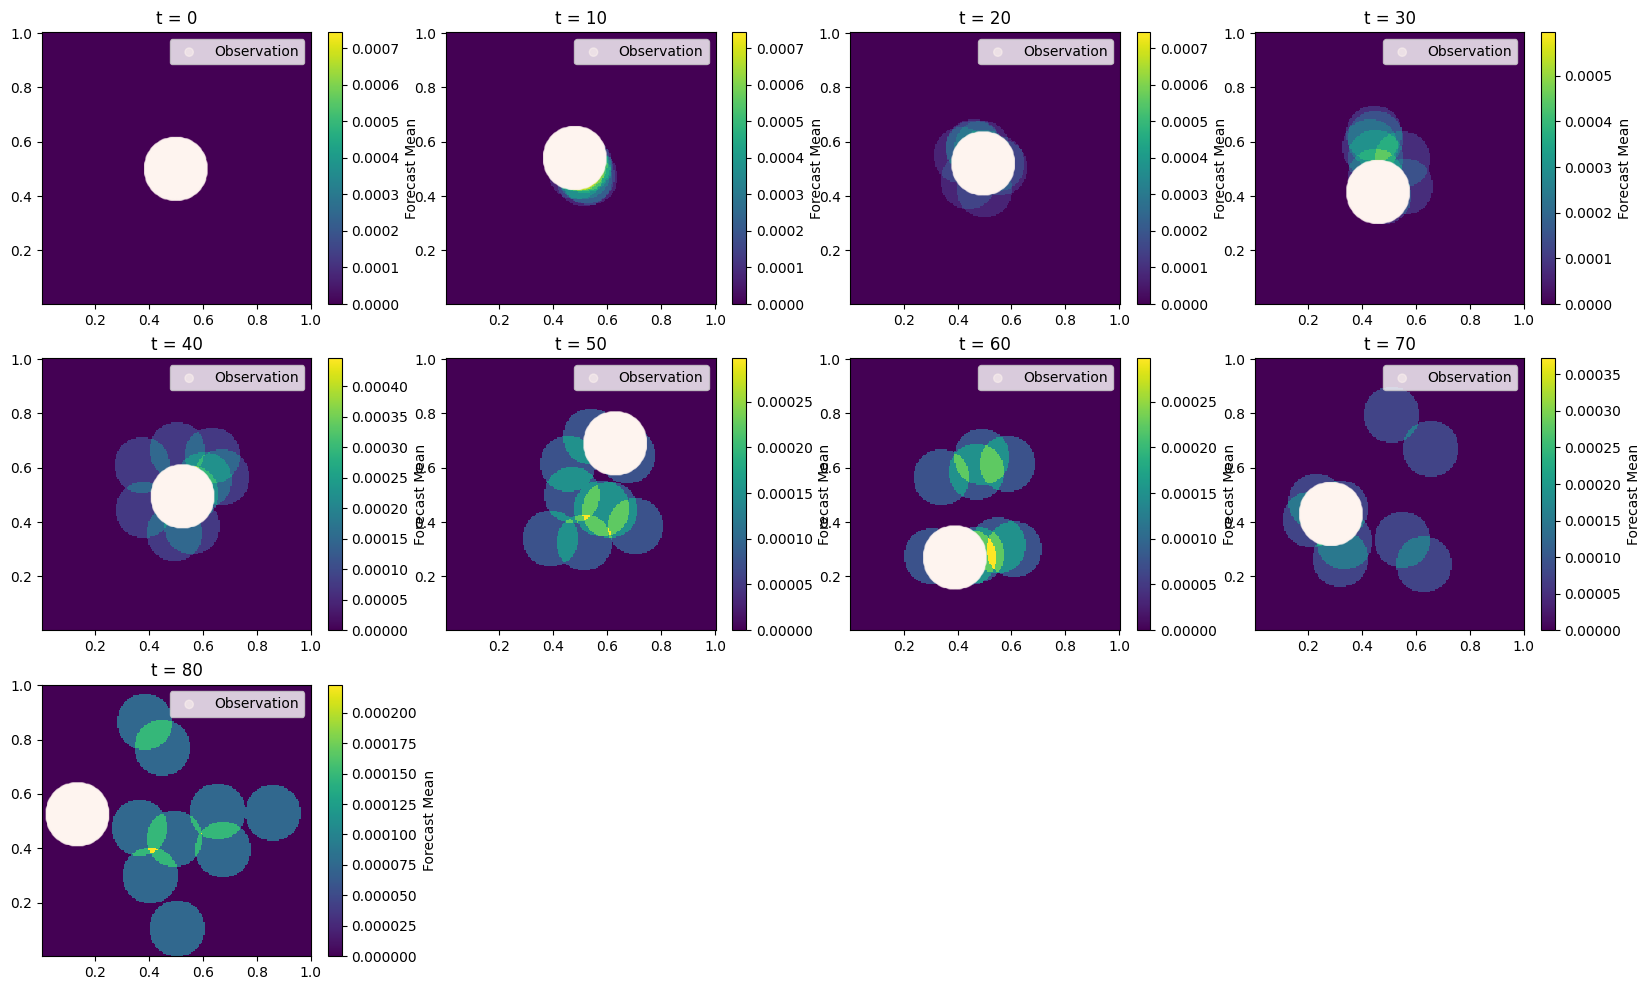

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_xx.png', dpi=300)

### Double penalty
Circles which are more and less perturbed

In [ ]:
# I should abstract this...
times = [0, 20, 40, 60, 80, 100]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        O, F, X = generate_double_penalty_circle_ensemble(mem, t, 20, path_to_data)

        data_list.append([F, None])

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


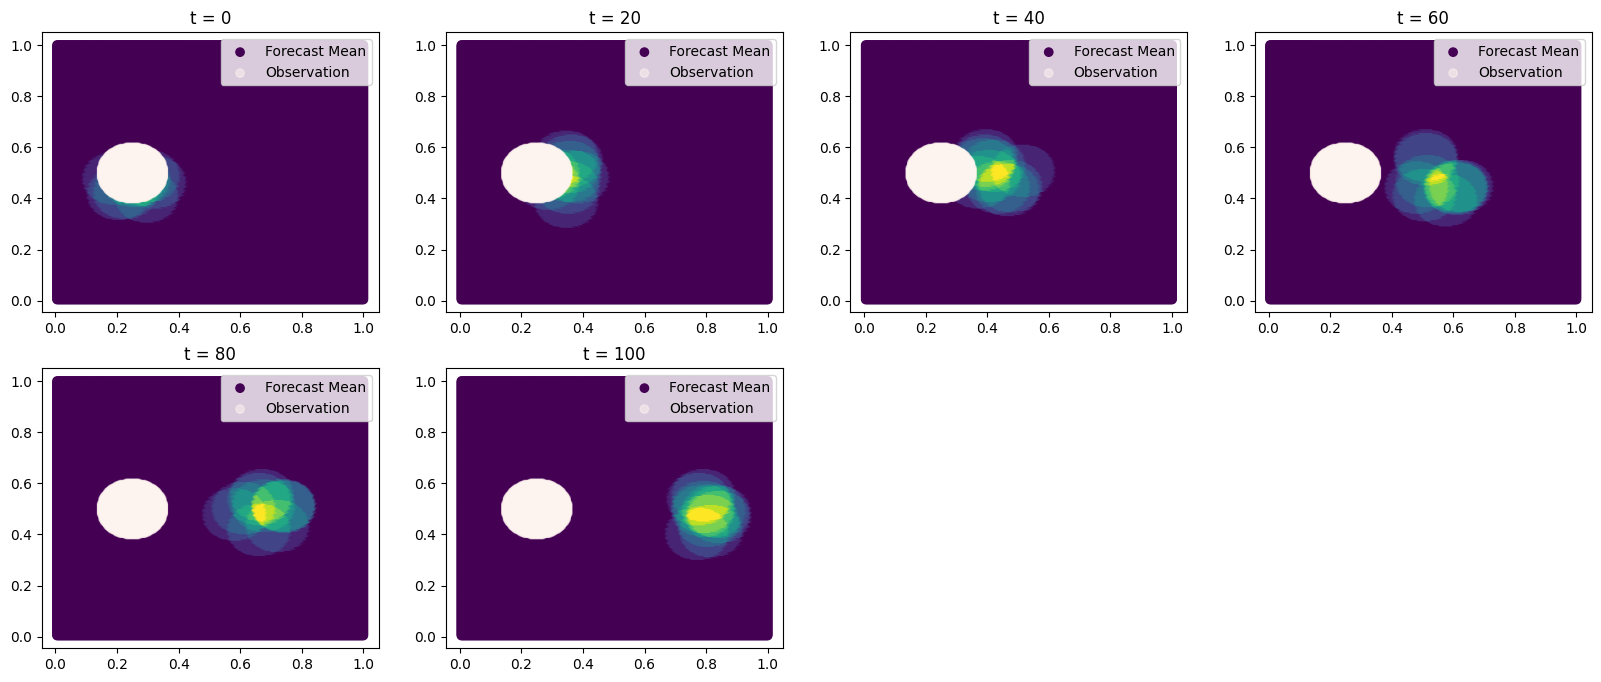

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.scatter(X[:, :, 0], X[:, :, 1], c=forecasts_mean, cmap='viridis', label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_2a.png', dpi=300)

In [ ]:
# I should abstract this...
times = [0, 20, 40, 60, 80, 100]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        O, F, X = generate_double_penalty_circle_ensemble(mem, t, 40, path_to_data)

        data_list.append([F, None])

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


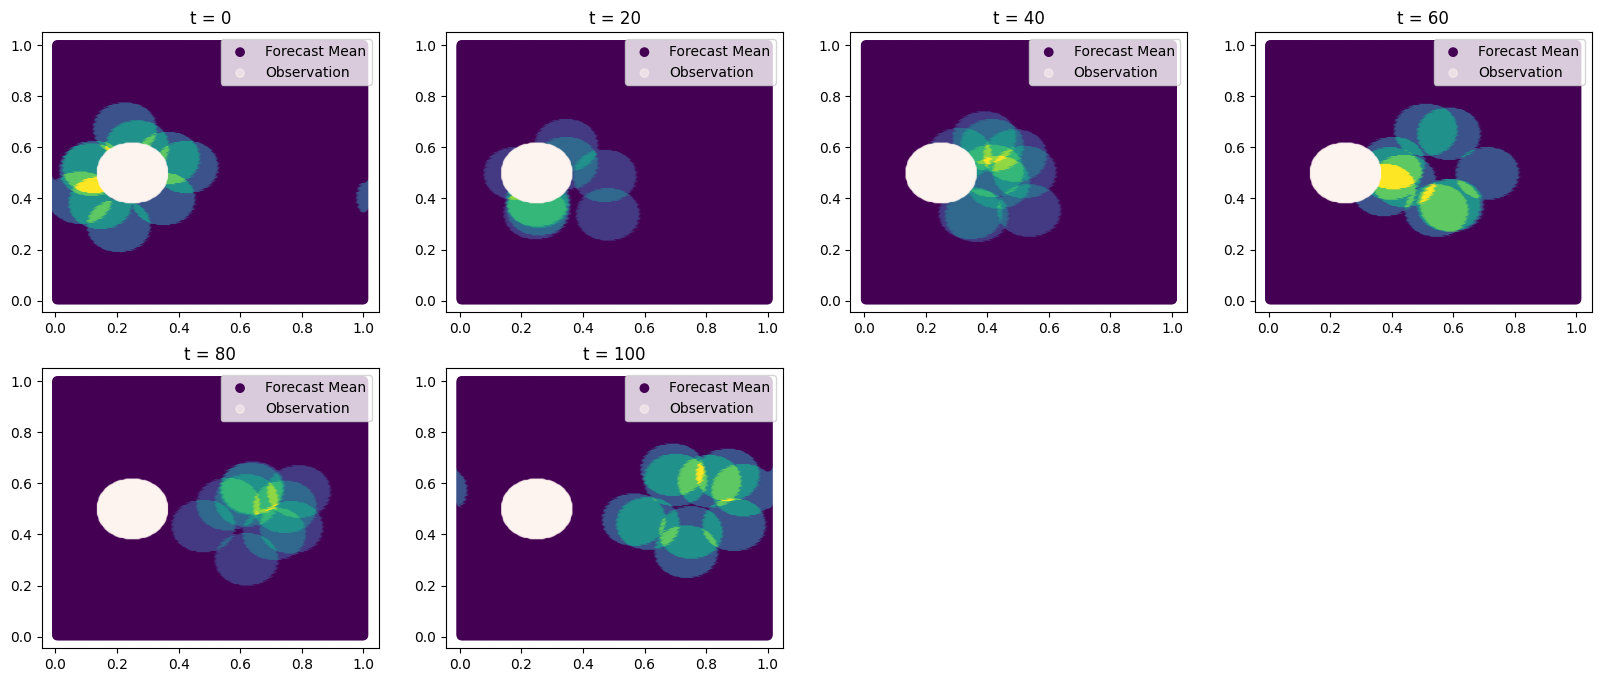

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.scatter(X[:, :, 0], X[:, :, 1], c=forecasts_mean, cmap='viridis', label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_2b.png', dpi=300)

### Cone section for testing over and under spread

In [ ]:

# I should abstract this...
times = [0, 20, 40, 60, 80, 100]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_cone_section_ensemble(mem, r1=t+10, r0=t, angle=np.deg2rad(45), path_to_data=path_to_data)

        data_list.append([F, None])
    
    O, X = generate_cone_section_ensemble(0, r1=t+20, r0=t, angle=np.deg2rad(45), path_to_data=path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


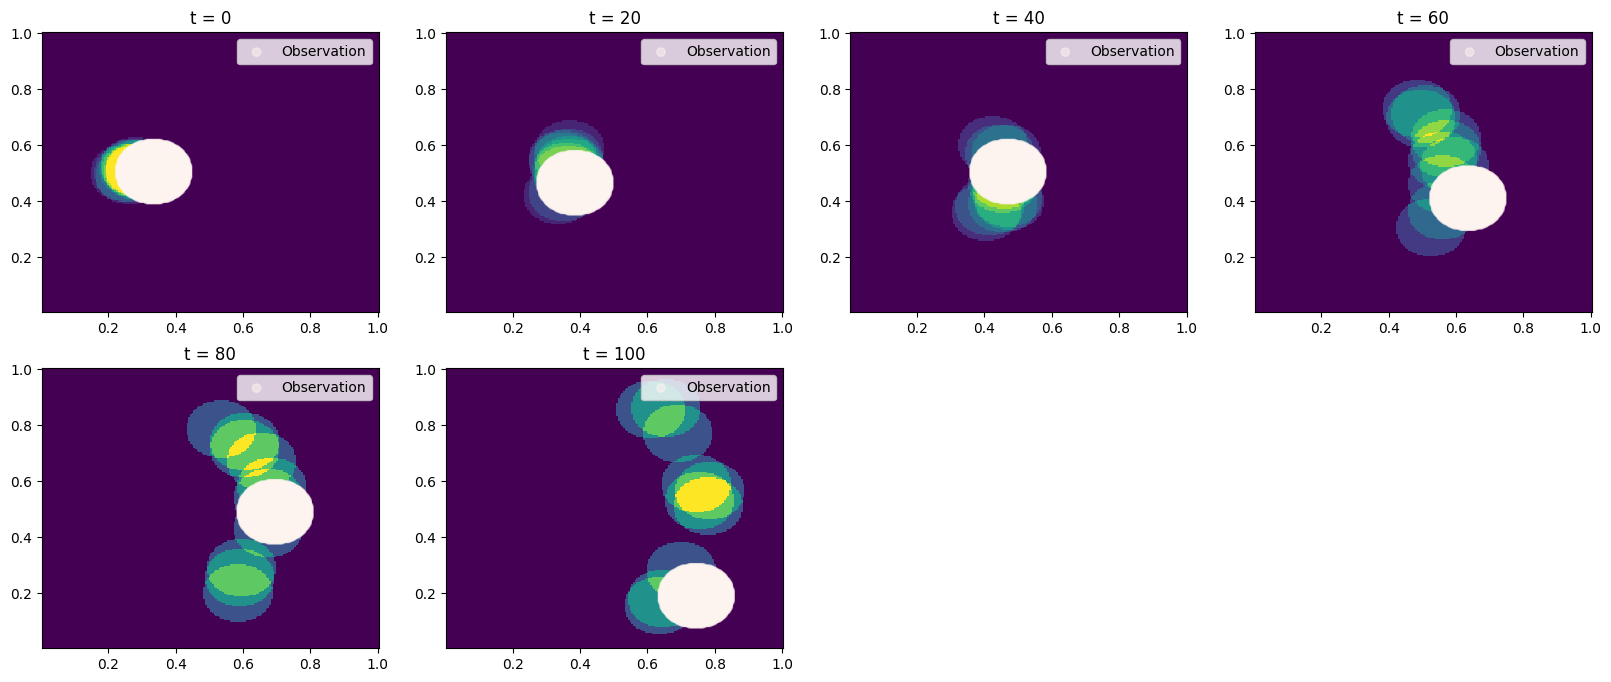

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_3a.png', dpi=300)

In [ ]:

# I should abstract this...
times = [0, 20, 40, 60, 80, 100]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_cone_section_ensemble(mem, r1=t+10, r0=t, angle=np.deg2rad(22.5), path_to_data=path_to_data)

        data_list.append([F, None])
    
    O, X = generate_cone_section_ensemble(0, r1=t+20, r0=t, angle=np.deg2rad(22.5), path_to_data=path_to_data)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


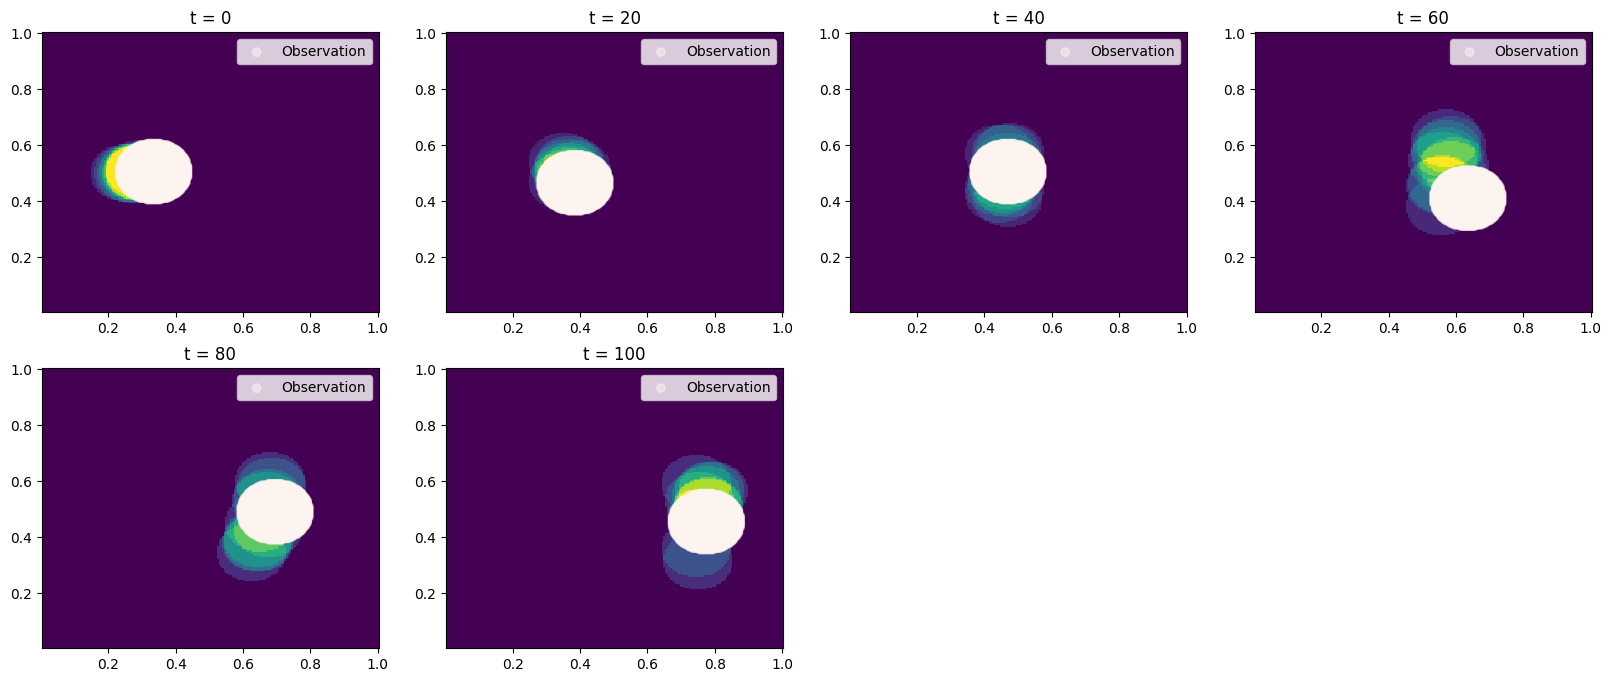

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_3b.png', dpi=300)

In [ ]:

# I should abstract this...
times = [0, 20, 40, 60, 80, 100]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        F, X = generate_cone_section_ensemble(mem, r1=t+10, r0=t, angle=np.deg2rad(90), path_to_data=path_to_data)

        data_list.append([F, None])
    
    O, X = generate_cone_section_ensemble(0, r1=t+20, r0=t, angle=np.deg2rad(90), path_to_data=path_to_data)
    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


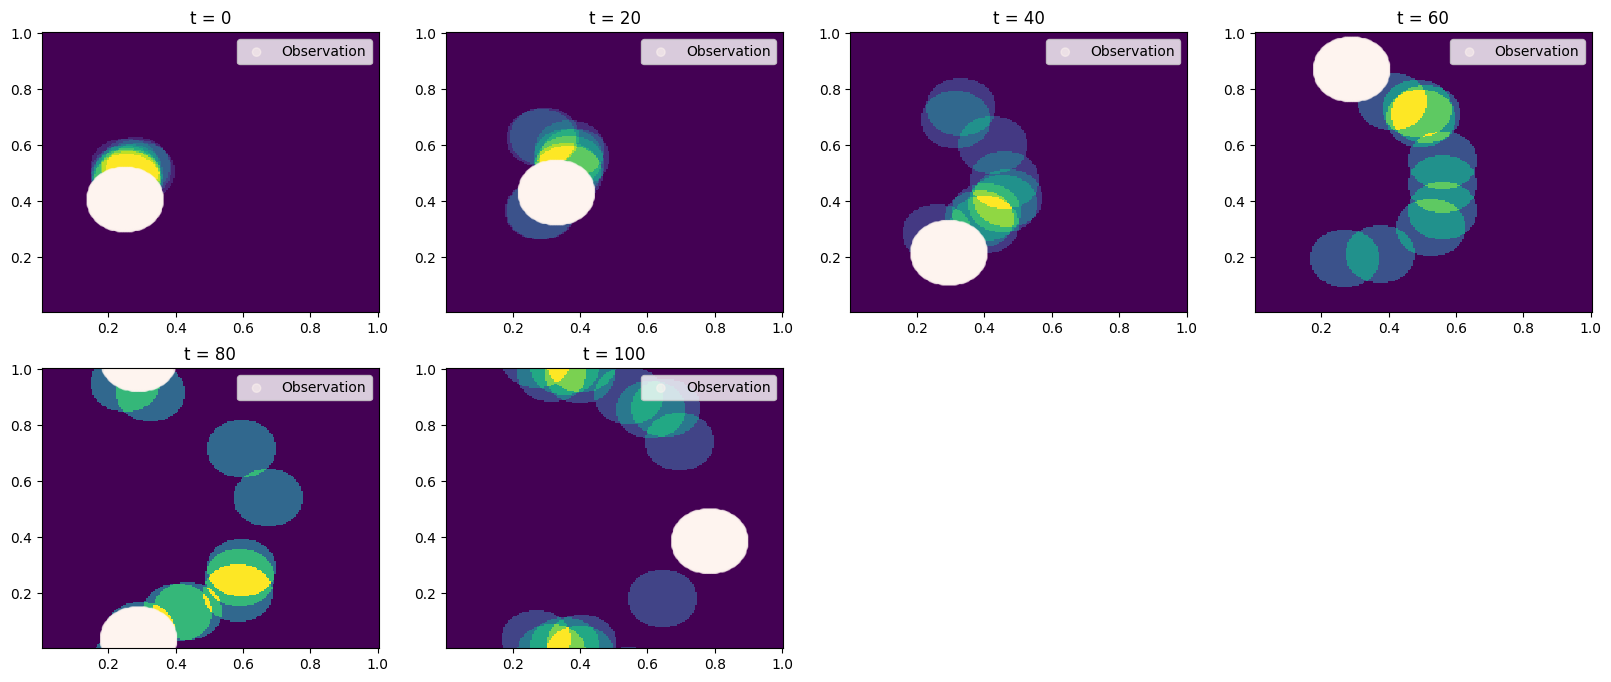

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_3c.png', dpi=300)

## Barycentre can form of the support

Can this be reduced with rho?

In [ ]:
# I should abstract this...
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
count = 0

# 1) Anulus
data_list = []
for mem in members:
    F, X = generate_cone_section_ensemble(mem, r1=60, r0=40, angle=0, path_to_data=path_to_data)
    F = np.roll(F, 50, axis=1) # roll back to centre
    data_list.append([F, None])

O, X = generate_cone_section_ensemble(0, r1=60, r0=40, angle=0, path_to_data=path_to_data)
O = np.roll(O, 50, axis=1) # roll back to centre

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )
count += 1 

# 2) Half cone section at 90 degrees
data_list = []
for mem in members:
    F, X = generate_cone_section_ensemble(mem, r1=60, r0=40, angle=np.deg2rad(90), path_to_data=path_to_data)

    data_list.append([F, None])

O, X = generate_cone_section_ensemble(0, r1=60, r0=40, angle=np.deg2rad(90), path_to_data=path_to_data)
dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )
count += 1 

# 3) two clusters - 1 event per

data_list = []
for mem in members:

    cluster = np.random.choice([-50, 50], size=1)
    F, X = generate_circle_ensemble(mem, 20, path_to_data, seed_pert=17)
    F = np.roll(F, cluster, axis=1)

    data_list.append([F, None])

cluster = np.random.choice([-50, 50], size=1)
O, X = generate_circle_ensemble(mem, 20, path_to_data, seed_pert=17)
O = np.roll(O, cluster, axis=1)

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )

count += 1 

# 4) two cluseters - 2 events per
data_list = []
for mem in members:

    F, X = generate_two_circle_event_clusters(mem, 20, [-50, 0], [50, 0], path_to_data, seed_pert=123)
    data_list.append([F, None])

O, X = generate_two_circle_event_clusters(0, 20, [-50, 0], [50, 0], path_to_data, seed_pert=123)

dictionary_in_time[count] = dict(
    observation = [O, None],
    forecasts = data_list
    )

count += 1 

dictionary_in_time['times'] = [k for k in range(count)]
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


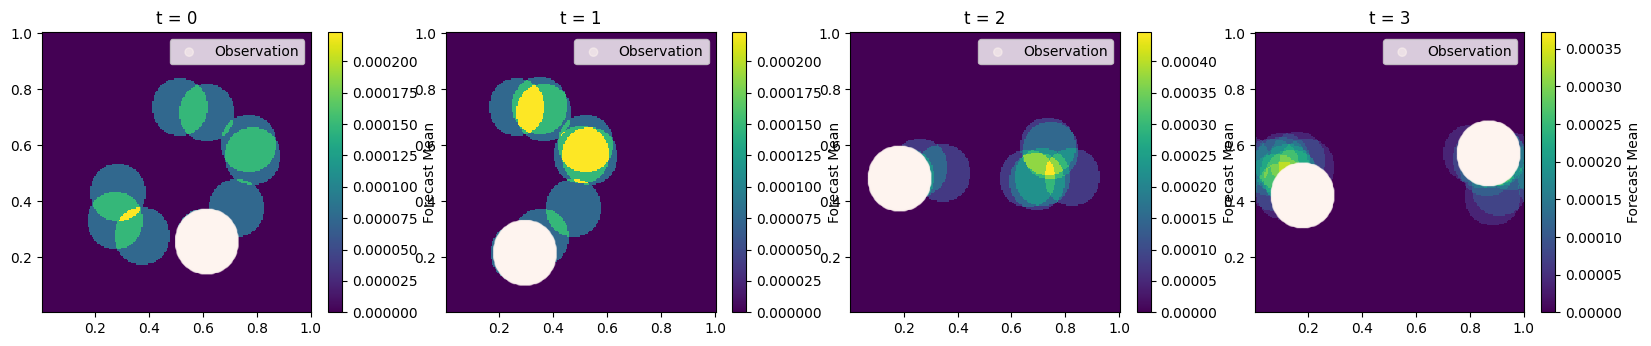

In [ ]:
T = len(dictionary_in_time['times'])
times = dictionary_in_time['times']
M = len(dictionary_in_time['members'])
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))


for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_4.png', dpi=300)

#### Bifurification/clustering of events

In [ ]:

# I should abstract this...
times = [0, 1, 2, 3, 4]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
clusters = [50, -50, -50, -50, -50, -50, -50, -50, -50, -50]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for k, mem in enumerate(members):
        cluster = clusters[k]
        F, X = generate_circle_ensemble(mem, 20, path_to_data, seed_pert=17*(t+1))
        F = np.roll(F, cluster, axis=1)

        data_list.append([F, None])
    
    # shuffle over a member
    clusters[t+1] = 50
    cluster = -50
    O, X = generate_circle_ensemble(mem, 20, path_to_data, seed_pert=17)
    O = np.roll(O, cluster, axis=1)

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )

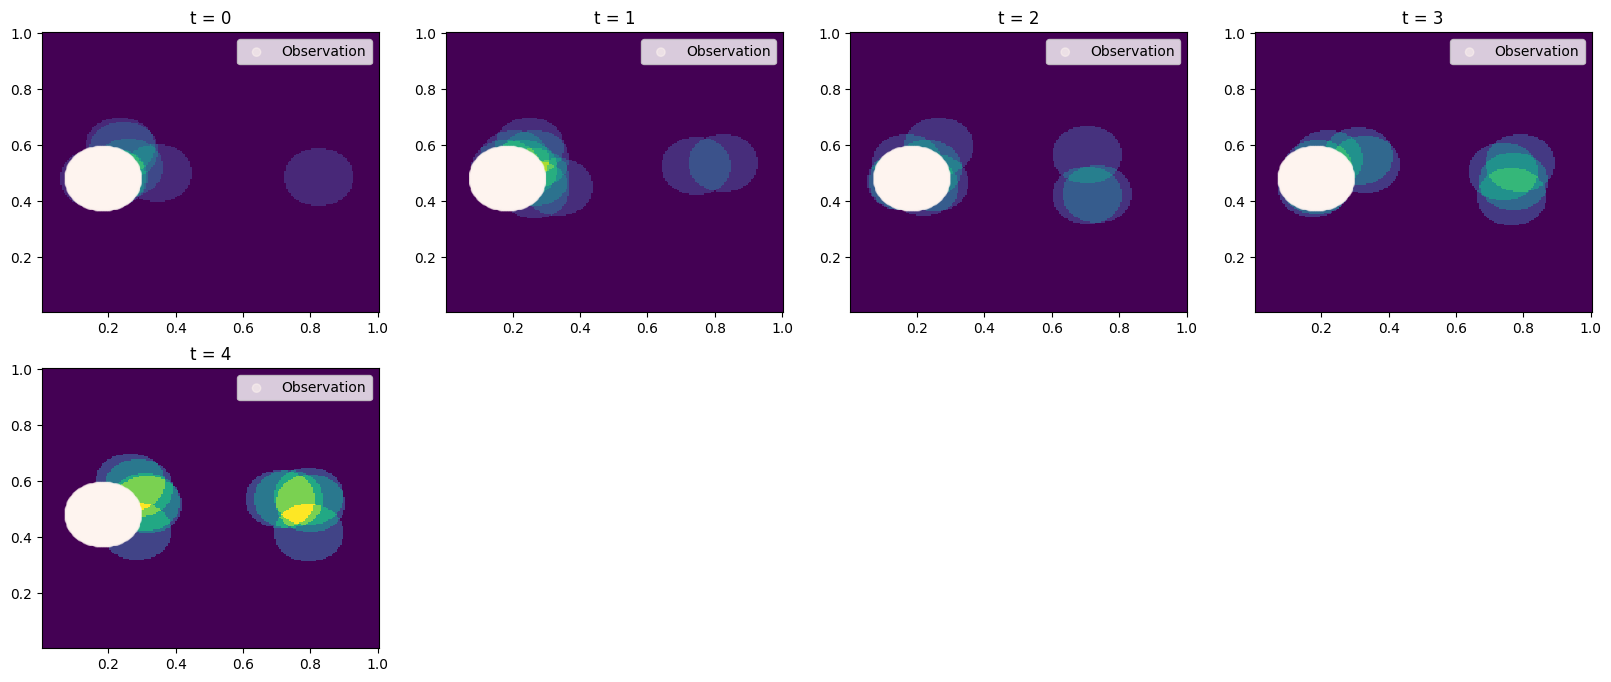

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_5.png', dpi=300)

### noisy

Startign with known double penalty and thus translational error, see how much noise ruins this

In [ ]:
# I should abstract this...
times = [1, 2, 4, 8, ]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        O, F, X = generate_double_penalty_circle_ensemble_with_noise(mem, 80, 20, 0.01*t, path_to_data)

        data_list.append([F, None])

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


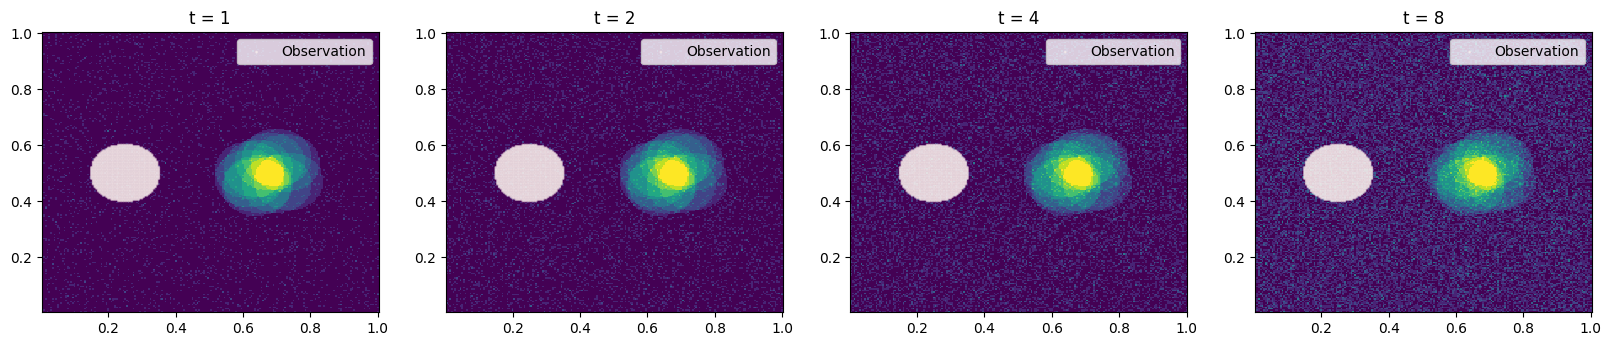

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation',s=1,  alpha=0.5)
    ax.legend()

plt.savefig('dataset_6.png', dpi=300)

# P1 and P2

In [ ]:
generate_case_ensemble

In [ ]:
# I should abstract this...
times = [0, 1]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        O, F, X = generate_case_ensemble('P2', path_to_data)

        data_list.append([F, None])

    if t == 1:
        # add zero memeber - P1
        data_list[0][0] *= 0 

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


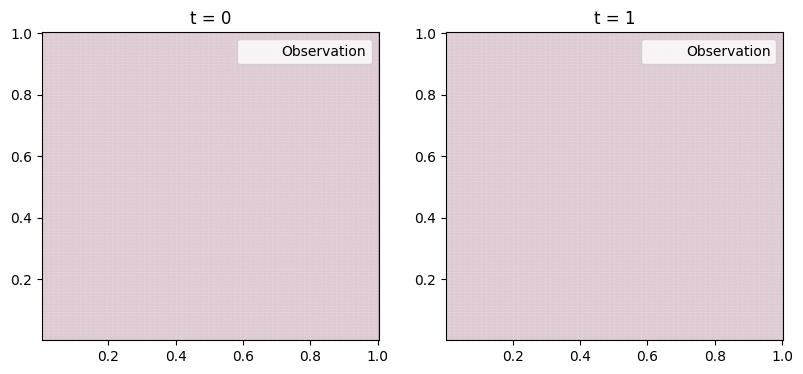

In [ ]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation',s=1,  alpha=0.5)
    ax.legend()

plt.savefig('dataset_7.png', dpi=300)

## Intensity error
Investigate intensity error, though with equal mass, thus just increases spatial bias - though for the spatial bias i want no intensity error, a.k.a don't normalise.

In [9]:
# I should abstract this...
times = [0, 5, 10, 15, 20, 25, 30]
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# Gather time series data
data_list = []
dictionary_in_time = {}
for t in times:
    data_list = []
    for mem in members:
        # rnage changed with t
        dia_vals = np.arange(40-t, 40+t+1)
        F, X = generate_circle_ensemble(mem, 0, path_to_data, seed_pert=42, diameter=np.random.choice(dia_vals))
        F /= F.sum()
        data_list.append([F, None])
    
    # generate the observation too as a random perturbation
    O, X = generate_circle_ensemble(0, 0, path_to_data)
    O /= O.sum()

    dictionary_in_time[t] = dict(
        observation = [O, None],
        forecasts = data_list
        )
dictionary_in_time['times'] = times
dictionary_in_time['members'] = members
dictionary_in_time['grid'] = X


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


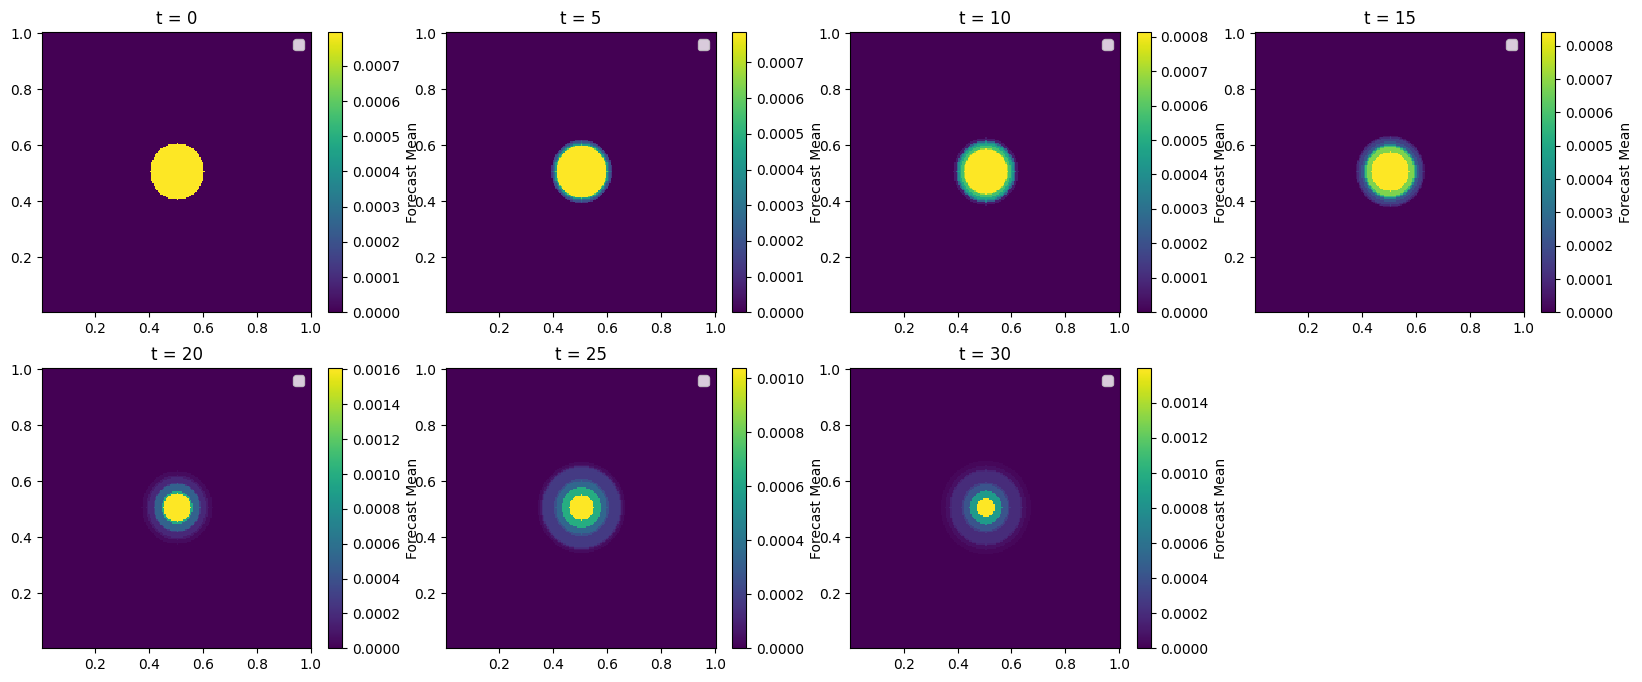

In [10]:
T = len(times)
M = len(members)
rows = (T//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:

    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    im = ax.pcolormesh(X[:, :, 0], X[:, :, 1], forecasts_mean, cmap='viridis')
    plt.colorbar(im, ax=ax, label='Forecast Mean')
    # ax.scatter(X[:, :, 0][obs[0]>0], X[:, :, 1][obs[0]>0], c=obs[0][obs[0]>0], cmap='Reds', label='Observation', alpha=0.5)
    ax.legend()

plt.savefig('dataset_8.png', dpi=300)